# CS-4063 — NLP Assignment 3: Transformer + RAG
## FAST NUCES — Transformer-based Review Understanding with RAG-Enhanced Explanation Generation

### Execution Instructions
1. Place the three `.gz` dataset files (`sports_json.gz`, `beauty_json.gz`, `cellphones_json.gz`) in the same directory as this notebook, or adjust `DATA_FILES` paths below.
2. Run all cells top-to-bottom via **Kernel → Restart & Run All**.
3. Trained weights will be saved in `models/`, embeddings in `results/`, plots and metrics in `results/`.
4. A GPU is strongly recommended (CUDA or MPS). On CPU, reduce `NUM_EPOCHS` and `BATCH_SIZE`.

### Directory Layout
```
.
├── i23XXXX-NLP-Assignment3.ipynb   ← this notebook
├── sports_json.gz
├── beauty_json.gz
├── cellphones_json.gz
├── models/                         ← saved weights (auto-created)
└── results/                        ← embeddings, metrics, plots (auto-created)
```

---
## 0. Imports & Global Configuration

In [4]:
import os, gzip, json, math, random, re, time, warnings
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
# GLOBAL CONFIG  — adjust these to tune the system
# ──────────────────────────────────────────────────────────────
SEED            = 42
REVIEWS_PER_CAT = 12_000   # 10k-15k per category as required
MAX_SEQ_LEN     = 128      # max tokens for encoder input
VOCAB_SIZE      = 20_000   # vocabulary size (built from train only)
EMBED_DIM       = 128      # embedding / model dimension
NUM_HEADS       = 4        # attention heads
FF_DIM          = 256      # feed-forward hidden size
NUM_ENC_LAYERS  = 2        # encoder transformer blocks
NUM_DEC_LAYERS  = 2        # decoder transformer blocks
DROPOUT         = 0.1
BATCH_SIZE      = 64
NUM_EPOCHS      = 8        # encoder training epochs
LR              = 3e-4
TOP_K           = 3        # retrieved neighbours for RAG
MAX_GEN_LEN     = 40       # max tokens to generate
DEC_EPOCHS      = 6        # decoder training epochs

DATA_FILES = [
    ('sports',      '/content/sports.json.gz'),
    ('beauty',      '/content/beauty.json.gz'),
    ('cellphones',  '/content/cellphones.json.gz'),
]

Path('models').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
## 1. Dataset Loading & Preprocessing

**Design choices:**
- Load 10k–15k reviews per category from the raw `.gz` JSONL files.
- Stratify by rating so all 5 star levels are proportionally represented.
- Text cleaning: lowercase, strip HTML, collapse whitespace, remove non-alphanumeric.
- Sentiment mapping: 1-2 → 0 (Negative), 3 → 1 (Neutral), 4-5 → 2 (Positive).
- **Derived feature:** review length bucket — short (≤30 tokens) → 0, medium (31-80) → 1, long (>80) → 2. Justified because length correlates with information density and can be predicted from text at training time (model must learn to count/structure), and it provides a useful auxiliary signal for the encoder.
- Vocabulary built **only** from training tokens.
- Padding/truncation to `MAX_SEQ_LEN`.

In [5]:
# ── 1.1 Text cleaning ──────────────────────────────────────────
def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags, collapse whitespace, keep alphanumeric."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'[^a-z0-9\s]', ' ', text)      # keep alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

def simple_tokenize(text: str) -> List[str]:
    return text.split()

def rating_to_sentiment(rating: float) -> int:
    if rating <= 2: return 0   # Negative
    if rating == 3: return 1   # Neutral
    return 2                   # Positive

SENTIMENT_NAMES = ['Negative', 'Neutral', 'Positive']
LENGTH_NAMES    = ['Short', 'Medium', 'Long']

def length_bucket(tokens: List[str]) -> int:
    n = len(tokens)
    if n <= 30: return 0
    if n <= 80: return 1
    return 2

In [6]:
# ── 1.2 Load raw data ──────────────────────────────────────────
def load_reviews(path: str, n: int, category: str) -> List[Dict]:
    records = []
    with gzip.open(path, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                obj = json.loads(line)
                text = obj.get('reviewText', '').strip()
                rating = float(obj.get('overall', 0))
                if text and 1 <= rating <= 5:
                    records.append({'text': text, 'rating': rating, 'category': category})
                    if len(records) >= n * 3:  # oversample, stratify later
                        break
            except:
                continue
    return records

def stratified_sample(records: List[Dict], n: int) -> List[Dict]:
    """Sample n reviews with roughly equal representation across ratings 1-5."""
    buckets = {i: [] for i in range(1, 6)}
    for r in records:
        buckets[int(r['rating'])].append(r)
    per_bucket = n // 5
    sampled = []
    for b in buckets.values():
        random.shuffle(b)
        sampled.extend(b[:per_bucket])
    random.shuffle(sampled)
    return sampled[:n]

all_records = []
for cat, path in DATA_FILES:
    raw = load_reviews(path, REVIEWS_PER_CAT, cat)
    sampled = stratified_sample(raw, REVIEWS_PER_CAT)
    all_records.extend(sampled)
    print(f'{cat}: loaded {len(sampled)} reviews')

random.shuffle(all_records)
print(f'\nTotal reviews: {len(all_records)}')

sports: loaded 9486 reviews
beauty: loaded 11587 reviews
cellphones: loaded 12000 reviews

Total reviews: 33073


In [7]:
# ── 1.3 Clean & tokenize, compute labels ──────────────────────
for r in all_records:
    tokens = simple_tokenize(clean_text(r['text']))
    r['tokens']    = tokens
    r['sentiment'] = rating_to_sentiment(r['rating'])
    r['len_label'] = length_bucket(tokens)

# ── 1.4 Train / Val / Test split 70/15/15 ────────────────────
N = len(all_records)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
train_data = all_records[:n_train]
val_data   = all_records[n_train:n_train+n_val]
test_data  = all_records[n_train+n_val:]
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Train: 23151 | Val: 4960 | Test: 4962


In [8]:
# ── 1.5 Build vocabulary from TRAINING data only ──────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

counter = Counter()
for r in train_data:
    counter.update(r['tokens'])

vocab_words = [w for w, _ in counter.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS))]
vocab = {tok: i for i, tok in enumerate(SPECIAL_TOKENS + vocab_words)}
inv_vocab = {i: w for w, i in vocab.items()}

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]
BOS_IDX = vocab[BOS_TOKEN]
EOS_IDX = vocab[EOS_TOKEN]
ACTUAL_VOCAB = len(vocab)
print(f'Vocabulary size: {ACTUAL_VOCAB}')

def encode(tokens: List[str], max_len: int) -> Tuple[List[int], int]:
    """Convert tokens to ids with truncation & padding. Returns (ids, length)."""
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    length = len(ids)
    ids = ids + [PAD_IDX] * (max_len - length)
    return ids, length

def decode(ids: List[int]) -> str:
    words = []
    for i in ids:
        if i == EOS_IDX: break
        if i not in (PAD_IDX, BOS_IDX):
            words.append(inv_vocab.get(i, UNK_TOKEN))
    return ' '.join(words)

Vocabulary size: 20000


In [18]:
# ── 1.6 PyTorch Datasets ──────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, records: List[Dict], max_len: int):
        self.records = records   # keep for text access outside DataLoader
        self.data = []
        for r in records:
            ids, length = encode(r['tokens'], max_len)
            self.data.append({
                'ids':       torch.tensor(ids,            dtype=torch.long),
                'mask':      torch.tensor([1]*length + [0]*(max_len-length), dtype=torch.bool),
                'sentiment': torch.tensor(r['sentiment'], dtype=torch.long),
                'len_label': torch.tensor(r['len_label'], dtype=torch.long),
                # NO 'text' or 'tokens' — raw strings/lists break default_collate
            })

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

train_ds = ReviewDataset(train_data, MAX_SEQ_LEN)
val_ds   = ReviewDataset(val_data,   MAX_SEQ_LEN)
test_ds  = ReviewDataset(test_data,  MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('Datasets ready.')

Datasets ready.


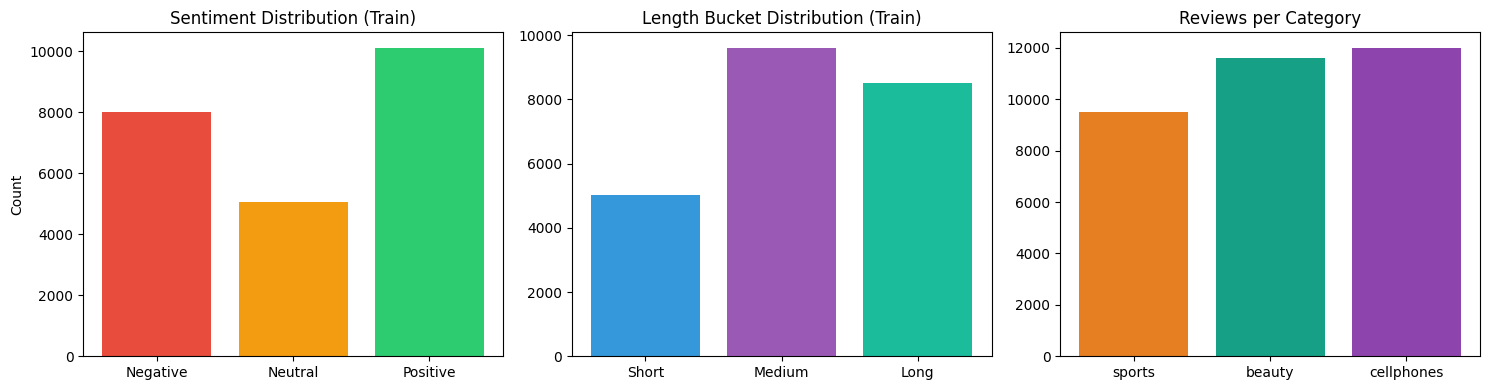

Plot saved.


In [19]:
# ── 1.7 Distribution plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sentiments = [r['sentiment'] for r in train_data]
axes[0].bar(SENTIMENT_NAMES, [sentiments.count(i) for i in range(3)], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Sentiment Distribution (Train)'); axes[0].set_ylabel('Count')

lens = [r['len_label'] for r in train_data]
axes[1].bar(LENGTH_NAMES, [lens.count(i) for i in range(3)], color=['#3498db','#9b59b6','#1abc9c'])
axes[1].set_title('Length Bucket Distribution (Train)')

cats = [r['category'] for r in all_records]
cat_names = list(dict.fromkeys(cats))
axes[2].bar(cat_names, [cats.count(c) for c in cat_names], color=['#e67e22','#16a085','#8e44ad'])
axes[2].set_title('Reviews per Category')

plt.tight_layout()
plt.savefig('results/data_distribution.png', dpi=150)
plt.show()
print('Plot saved.')

---
## 2. Part A — Encoder-Only Transformer (Multi-Task Learning)

**Architecture:**
- Learned token embedding + sinusoidal positional encoding
- N stacked encoder blocks, each with:
  - Scaled dot-product multi-head self-attention (no `nn.MultiheadAttention`)
  - Residual connection + LayerNorm
  - Position-wise feed-forward (2-layer MLP)
  - Residual connection + LayerNorm
- CLS-token aggregation for classification
- Two classification heads: sentiment (3-class) and length bucket (3-class)
- Combined loss: equal weighting of the two cross-entropy losses

In [20]:
# ── 2.1 Positional Encoding ───────────────────────────────────
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)              # (L, D)
        pos = torch.arange(max_len).unsqueeze(1)        # (L, 1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))     # (1, L, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, D)
        return self.dropout(x + self.pe[:, :x.size(1)])

In [21]:
# ── 2.2 Scaled Dot-Product Attention (from scratch) ───────────
class ScaledDotProductAttention(nn.Module):
    """Computes Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V."""
    def __init__(self, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        # Q,K,V: (B, H, L, d_k)
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B,H,L,L)
        if mask is not None:
            # mask: (B,1,1,L) for padding, or (B,1,L,L) for causal
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)           # (B,H,L,L)
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn             # (B,H,L,d_k), (B,H,L,L)

In [22]:
# ── 2.3 Multi-Head Attention (from scratch) ───────────────────
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention: projects input to H independent Q/K/V subspaces,
    applies scaled dot-product attention in each head, then concatenates
    and projects back to d_model.
    """
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # Separate linear projections for Q, K, V per head (fused into single matrix for efficiency)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.attn = ScaledDotProductAttention(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, L, D) → (B, H, L, d_k)"""
        B, L, _ = x.shape
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, H, L, d_k) → (B, L, D)"""
        B, H, L, dk = x.shape
        return x.transpose(1, 2).contiguous().view(B, L, H * dk)

    def forward(self, query, key, value, mask=None):
        Q = self._split_heads(self.W_Q(query))   # (B, H, L, d_k)
        K = self._split_heads(self.W_K(key))
        V = self._split_heads(self.W_V(value))

        out, _ = self.attn(Q, K, V, mask)        # (B, H, L, d_k)
        out = self._merge_heads(out)              # (B, L, D)
        return self.W_O(out)                      # (B, L, D)

In [23]:
# ── 2.4 Position-wise Feed-Forward ───────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


# ── 2.5 Encoder Block ────────────────────────────────────────
class EncoderBlock(nn.Module):
    """
    One encoder block:
      x → [LayerNorm → MultiHeadSelfAttention] → residual
        → [LayerNorm → FeedForward]             → residual
    (Pre-LN variant for more stable training.)
    """
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = FeedForward(d_model, ff_dim, dropout)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        # pad_mask: (B, 1, 1, L) — 1 for real tokens, 0 for padding
        normed = self.norm1(x)
        x = x + self.drop(self.attn(normed, normed, normed, pad_mask))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

In [24]:
# ── 2.6 Full Encoder Model ────────────────────────────────────
class TransformerEncoder(nn.Module):
    """
    Encoder-only Transformer for multi-task classification.
    Outputs:
      - sentiment_logits  (B, 3)
      - len_logits        (B, 3)
      - embedding         (B, d_model)  ← CLS representation
    """
    def __init__(self, vocab_size, d_model, num_heads, ff_dim,
                 num_layers, max_len, dropout, num_sent=3, num_len=3):
        super().__init__()
        self.d_model    = d_model
        self.embed      = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc    = PositionalEncoding(d_model, max_len + 1, dropout)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))   # learnable CLS
        self.layers     = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.sent_head  = nn.Linear(d_model, num_sent)
        self.len_head   = nn.Linear(d_model, num_len)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_pad_mask(self, ids: torch.Tensor) -> torch.Tensor:
        """Build (B, 1, 1, L+1) mask: 1=attend, 0=ignore."""
        # ids: (B, L); prepend 1 for CLS
        B = ids.size(0)
        cls_mask = torch.ones(B, 1, dtype=torch.bool, device=ids.device)
        tok_mask = (ids != PAD_IDX)                  # (B, L)
        full_mask = torch.cat([cls_mask, tok_mask], dim=1)   # (B, L+1)
        return full_mask.unsqueeze(1).unsqueeze(2)           # (B,1,1,L+1)

    def forward(self, ids: torch.Tensor):
        B = ids.size(0)
        pad_mask = self.make_pad_mask(ids)

        tok_emb = self.embed(ids) * math.sqrt(self.d_model)  # (B, L, D)
        cls_emb = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x = torch.cat([cls_emb, tok_emb], dim=1)             # (B, L+1, D)
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, pad_mask)

        x = self.norm(x)
        cls_rep = x[:, 0, :]                                  # (B, D)
        return self.sent_head(cls_rep), self.len_head(cls_rep), cls_rep

In [25]:
# ── 2.7 Training Loop ─────────────────────────────────────────
encoder = TransformerEncoder(
    vocab_size=ACTUAL_VOCAB, d_model=EMBED_DIM, num_heads=NUM_HEADS,
    ff_dim=FF_DIM, num_layers=NUM_ENC_LAYERS, max_len=MAX_SEQ_LEN,
    dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'Encoder parameters: {total_params:,}')

optimizer   = AdamW(encoder.parameters(), lr=LR, weight_decay=1e-2)
scheduler   = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
sent_loss_fn = nn.CrossEntropyLoss()
len_loss_fn  = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    encoder.train(train)
    total_loss = total_sent = total_len = 0
    sent_correct = len_correct = total_samples = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids  = batch['ids'].to(DEVICE)
            sent = batch['sentiment'].to(DEVICE)
            lenl = batch['len_label'].to(DEVICE)

            s_logit, l_logit, _ = encoder(ids)
            s_loss = sent_loss_fn(s_logit, sent)
            l_loss = len_loss_fn(l_logit, lenl)
            loss   = s_loss + l_loss              # equal weighting

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
                optimizer.step()

            B = ids.size(0)
            total_loss   += loss.item() * B
            total_sent   += s_loss.item() * B
            total_len    += l_loss.item() * B
            sent_correct += (s_logit.argmax(-1) == sent).sum().item()
            len_correct  += (l_logit.argmax(-1) == lenl).sum().item()
            total_samples += B

    return {
        'loss': total_loss / total_samples,
        'sent_loss': total_sent / total_samples,
        'len_loss':  total_len  / total_samples,
        'sent_acc':  sent_correct / total_samples,
        'len_acc':   len_correct  / total_samples,
    }

history = {'train': [], 'val': []}
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    scheduler.step()
    history['train'].append(tr)
    history['val'].append(vl)

    if vl['loss'] < best_val_loss:
        best_val_loss = vl['loss']
        torch.save(encoder.state_dict(), 'models/encoder_best.pt')

    print(f'Epoch {epoch}/{NUM_EPOCHS} ({time.time()-t0:.1f}s) '
          f'| Train Loss {tr["loss"]:.4f} | Val Loss {vl["loss"]:.4f} '
          f'| Train SentAcc {tr["sent_acc"]:.3f} | Val SentAcc {vl["sent_acc"]:.3f} '
          f'| Train LenAcc {tr["len_acc"]:.3f} | Val LenAcc {vl["len_acc"]:.3f}')

torch.save(encoder.state_dict(), 'models/encoder_final.pt')
print('\nEncoder training complete.')

Encoder parameters: 2,825,094
Epoch 1/8 (7.2s) | Train Loss 1.0320 | Val Loss 0.8344 | Train SentAcc 0.525 | Val SentAcc 0.642 | Train LenAcc 0.983 | Val LenAcc 0.997
Epoch 2/8 (6.5s) | Train Loss 0.7463 | Val Loss 0.7750 | Train SentAcc 0.681 | Val SentAcc 0.664 | Train LenAcc 0.998 | Val LenAcc 0.998
Epoch 3/8 (6.7s) | Train Loss 0.5853 | Val Loss 0.8536 | Train SentAcc 0.756 | Val SentAcc 0.657 | Train LenAcc 0.999 | Val LenAcc 0.998
Epoch 4/8 (6.5s) | Train Loss 0.4068 | Val Loss 1.1339 | Train SentAcc 0.842 | Val SentAcc 0.623 | Train LenAcc 0.999 | Val LenAcc 0.997
Epoch 5/8 (6.5s) | Train Loss 0.2711 | Val Loss 1.4725 | Train SentAcc 0.902 | Val SentAcc 0.607 | Train LenAcc 0.999 | Val LenAcc 0.997
Epoch 6/8 (6.6s) | Train Loss 0.1888 | Val Loss 1.6847 | Train SentAcc 0.933 | Val SentAcc 0.623 | Train LenAcc 0.999 | Val LenAcc 0.997
Epoch 7/8 (6.6s) | Train Loss 0.1380 | Val Loss 1.9295 | Train SentAcc 0.952 | Val SentAcc 0.611 | Train LenAcc 1.000 | Val LenAcc 0.997
Epoch 8/8 (

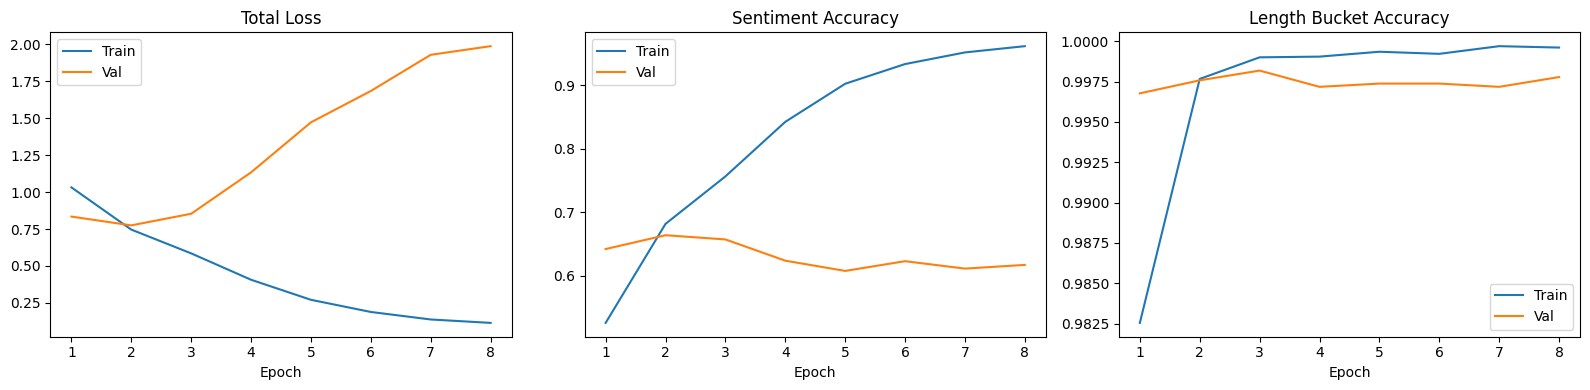

In [26]:
# ── 2.8 Learning Curves ───────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, [h['loss'] for h in history['train']], label='Train')
axes[0].plot(epochs, [h['loss'] for h in history['val']],   label='Val')
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, [h['sent_acc'] for h in history['train']], label='Train')
axes[1].plot(epochs, [h['sent_acc'] for h in history['val']],   label='Val')
axes[1].set_title('Sentiment Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, [h['len_acc'] for h in history['train']], label='Train')
axes[2].plot(epochs, [h['len_acc'] for h in history['val']],   label='Val')
axes[2].set_title('Length Bucket Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=150)
plt.show()

=== Sentiment Classification Report ===
              precision    recall  f1-score   support

    Negative       0.71      0.74      0.72      1715
     Neutral       0.40      0.40      0.40      1092
    Positive       0.76      0.74      0.75      2155

    accuracy                           0.66      4962
   macro avg       0.62      0.62      0.62      4962
weighted avg       0.66      0.66      0.66      4962

=== Length Bucket Classification Report ===
              precision    recall  f1-score   support

       Short       1.00      1.00      1.00      1014
      Medium       1.00      1.00      1.00      2105
        Long       1.00      1.00      1.00      1843

    accuracy                           1.00      4962
   macro avg       1.00      1.00      1.00      4962
weighted avg       1.00      1.00      1.00      4962



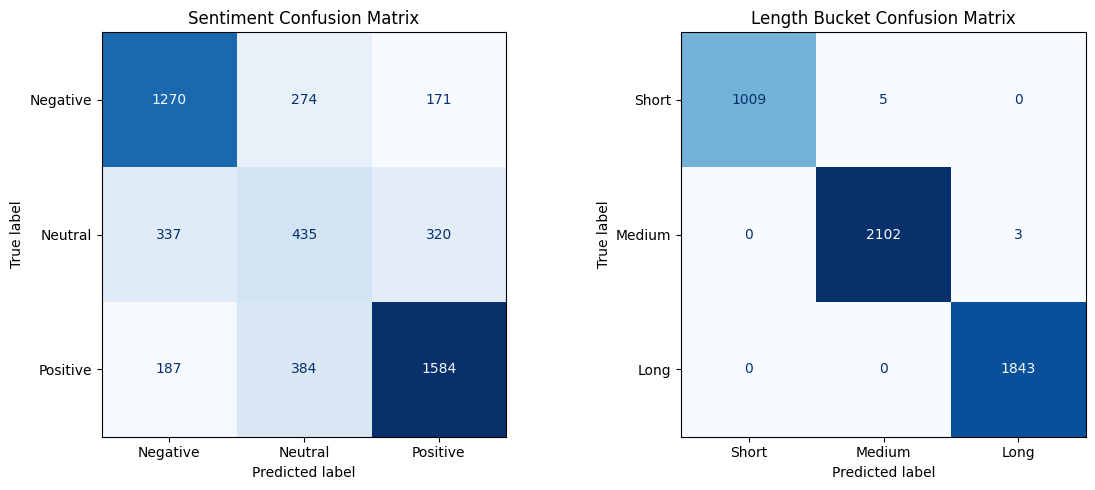

In [27]:
# ── 2.9 Test Evaluation ───────────────────────────────────────
encoder.load_state_dict(torch.load('models/encoder_best.pt', map_location=DEVICE))
encoder.eval()

all_s_preds, all_s_true = [], []
all_l_preds, all_l_true = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['ids'].to(DEVICE)
        s_logit, l_logit, _ = encoder(ids)
        all_s_preds.extend(s_logit.argmax(-1).cpu().tolist())
        all_s_true.extend(batch['sentiment'].tolist())
        all_l_preds.extend(l_logit.argmax(-1).cpu().tolist())
        all_l_true.extend(batch['len_label'].tolist())

print('=== Sentiment Classification Report ===')
print(classification_report(all_s_true, all_s_preds, target_names=SENTIMENT_NAMES))

print('=== Length Bucket Classification Report ===')
print(classification_report(all_l_true, all_l_preds, target_names=LENGTH_NAMES))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_true, y_pred, names, title in [
    (axes[0], all_s_true, all_s_preds, SENTIMENT_NAMES, 'Sentiment'),
    (axes[1], all_l_true, all_l_preds, LENGTH_NAMES,    'Length Bucket'),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix')
plt.tight_layout()
plt.savefig('results/encoder_confusion_matrices.png', dpi=150)
plt.show()

In [29]:
# ── 2.10 Save Training Embeddings for Retrieval ───────────────
# ── 2.10 Save Training Embeddings for Retrieval ───────────────
print('Extracting and saving training embeddings...')
encoder.eval()

train_loader_noshuffle = DataLoader(train_ds, batch_size=256, shuffle=False, num_workers=0)
embeddings_list, sent_list, len_list = [], [], []

with torch.no_grad():
    for batch in train_loader_noshuffle:
        ids = batch['ids'].to(DEVICE)
        _, _, emb = encoder(ids)
        embeddings_list.append(emb.cpu().numpy())
        sent_list.extend(batch['sentiment'].tolist())
        len_list.extend(batch['len_label'].tolist())

# Pull texts directly from the dataset records (not from batch)
texts_list = [r['text'] for r in train_ds.records]

train_embeddings = np.vstack(embeddings_list)   # (N_train, D)
train_sentiments = np.array(sent_list)
train_len_labels = np.array(len_list)

np.save('results/train_embeddings.npy', train_embeddings)
np.save('results/train_sentiments.npy', train_sentiments)
np.save('results/train_len_labels.npy', train_len_labels)
with open('results/train_texts.json', 'w') as f:
    json.dump(texts_list, f)

print(f'Saved train_embeddings.npy: shape {train_embeddings.shape}')

Extracting and saving training embeddings...
Saved train_embeddings.npy: shape (23151, 128)
